# 04 — Locomotor resilience

Quantifies the impact of the sand perturbation by comparing **inside-the-sand-bed** metrics with **other corridor passages** (baseline).

## Method (hybrid bbox + PCA)

1. Compute 3 resilience signals from the vertical sacrum trace:
   - `sig_var`     — rolling variance (1 s window) → vertical variability
   - `sig_radius`  — phase-space radius (distance to TDE centroid) → dynamic dispersion
   - `sig_cadence` — local dominant frequency (Welch) → instantaneous cadence
2. **Perturbation** = longest bbox segment (precise, median error ≈ 0 s vs CRF)
3. **Baseline** = other corridor passages detected via PCA-calibrated corridor (statistically valid: same circuit phase as perturbation)
4. Per-trial metrics: `z_var`, `z_radius`, `ratio_var`, `ratio_radius`, `delta_cadence_hz`

Exploitability criterion: at least 3 valid baseline passages, otherwise the trial is recorded with NaN metrics.

## Inputs / Outputs

- **Inputs**  : `data/processed/*.npz`, `outputs/tables/03_tde_per_participant.csv`
- **Outputs** : `outputs/tables/04_resilience_metrics.csv`, `outputs/figures/04_metrics_by_condition.png`, `outputs/figures/04_individual_trajectories.png`

In [2]:
from resilience import paths
from resilience.analysis import resilience_workflow
from resilience.viz import plots

from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline

OUT_FIGURES = Path(paths.OUTPUTS_DIR) / 'figures'

## 1. Run pipeline

In [3]:
tde_params = resilience_workflow.load_tde_params()
pca_calibs = resilience_workflow.calibrate_all_participants()
trials     = resilience_workflow.load_all_trials(pca_calibs)

print(f"\n✅ {len(trials)} trials loaded")

C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\src\resilience\analysis\resilience_workflow.py:116: RuntimeWarning: Mean of empty slice
  sacrum_xy = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\src\resilience\analysis\resilience_workflow.py:116: RuntimeWarning: Mean of empty slice
  sacrum_xy = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\src\resilience\analysis\resilience_workflow.py:116: RuntimeWarning: Mean of empty slice
  sacrum_xy = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\src\resilience\analysis\resilience_workflow.py:116: RuntimeWarning: Mean of empty slice
  sacrum_xy = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\src\resilience\analysis\resilience_workflow.py:116: RuntimeWarning: Mean of empty slice
  sacrum_xy = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\Desktop\MASTER_IEAP\IN

  ⚠️  006MoCa: CRF manquante pour 006MoCa/beatmove_adaptatif. Compléter participants.py.


C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\src\resilience\analysis\resilience_workflow.py:116: RuntimeWarning: Mean of empty slice
  sacrum_xy = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\src\resilience\analysis\resilience_workflow.py:116: RuntimeWarning: Mean of empty slice
  sacrum_xy = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\src\resilience\analysis\resilience_workflow.py:116: RuntimeWarning: Mean of empty slice
  sacrum_xy = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\src\resilience\analysis\resilience_workflow.py:116: RuntimeWarning: Mean of empty slice
  sacrum_xy = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\src\resilience\analysis\resilience_workflow.py:116: RuntimeWarning: Mean of empty slice
  sacrum_xy = np.nanmean(dos_xy, axis=0)
C:\Users\etulyon1\Desktop\MASTER_IEAP\IN

  ✅ 13 participants PCA-calibrated


C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\src\resilience\analysis\resilience_workflow.py:116: RuntimeWarning: Mean of empty slice
  sacrum_xy = np.nanmean(dos_xy, axis=0)



✅ 35 trials loaded


In [4]:
df_res, signals_cache = resilience_workflow.compute_metrics(trials, tde_params)
print(f"\n✅ {len(df_res)} trials analysed")
df_res

C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\src\resilience\analysis\resilience_workflow.py:294: RuntimeWarning: Mean of empty slice
  bcads.append(float(np.nanmean(signals['sig_cadence'][msk])))



✅ 35 trials analysed


,participant,condition,n_baseline_passages,pert_duration_s,pert_var,pert_radius,pert_cadence,baseline_var,baseline_radius,baseline_cadence,z_var,z_radius,ratio_var,ratio_radius,delta_cadence_hz
0,001CrMa,silence,32,4.86,168.73,26.67,1.617,121.81,22.56,1.843,3.00,2.63,1.39,1.18,-0.226
1,001CrMa,tempo_random,41,4.35,247.61,32.61,1.680,147.51,24.53,1.895,1.40,2.07,1.68,1.33,-0.214
2,001CrMa,beatmove_adaptatif,18,4.18,455.98,52.16,1.718,171.59,26.16,1.864,10.58,11.81,2.66,1.99,-0.146
3,002CrPa,silence,20,4.96,118.78,22.34,1.000,83.92,18.37,1.875,4.28,4.46,1.42,1.22,-0.875
4,002CrPa,beatmove_adaptatif,18,4.93,112.15,22.01,1.215,72.25,16.99,1.675,5.73,5.46,1.55,1.30,-0.460
5,002CrPa,tempo_random,18,4.95,155.56,26.87,1.404,70.55,16.75,1.687,12.37,8.99,2.20,1.60,-0.283
6,003BrLu,silence,44,3.97,171.00,26.23,2.000,128.81,22.75,1.769,0.78,0.58,1.33,1.15,0.231
7,003BrLu,tempo_random,39,3.84,255.32,31.98,1.953,178.37,26.39,1.717,2.16,2.01,1.43,1.21,0.236
8,003BrLu,beatmove_adaptatif,49,3.91,319.15,38.76,1.555,187.04,27.65,NaN,4.36,5.24,1.71,1.40,NaN
9,004CaGe,silence,18,3.93,259.76,33.54,2.000,141.23,24.40,1.942,11.08,10.04,1.84,1.37,0.058


## 2. Descriptive stats per condition

In [5]:
metric_cols = ['z_var', 'z_radius', 'ratio_var', 'ratio_radius', 'delta_cadence_hz']
for col in metric_cols:
    print(f"\n--- {col} ---")
    print(df_res.groupby('condition')[col].describe()[['count', '25%', '50%', '75%']].round(2))


--- z_var ---
                    count   25%   50%    75%
condition                                   
beatmove_adaptatif   12.0  4.26  5.26   7.41
silence              11.0  2.64  3.36   6.92
tempo_random         12.0  4.34  6.30  10.73

--- z_radius ---
                    count   25%   50%   75%
condition                                  
beatmove_adaptatif   12.0  3.61  4.68  6.35
silence              11.0  2.58  2.92  6.62
tempo_random         12.0  2.84  4.77  6.44

--- ratio_var ---
                    count   25%   50%   75%
condition                                  
beatmove_adaptatif   12.0  1.42  1.54  2.04
silence              11.0  1.39  1.49  1.72
tempo_random         12.0  1.62  1.85  2.15

--- ratio_radius ---
                    count   25%   50%   75%
condition                                  
beatmove_adaptatif   12.0  1.19  1.27  1.41
silence              11.0  1.20  1.25  1.34
tempo_random         12.0  1.30  1.36  1.54

--- delta_cadence_hz ---
               

## 3. Plots

   ✅ Figure sauvegardée : C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\outputs\figures\04_metrics_by_condition.png


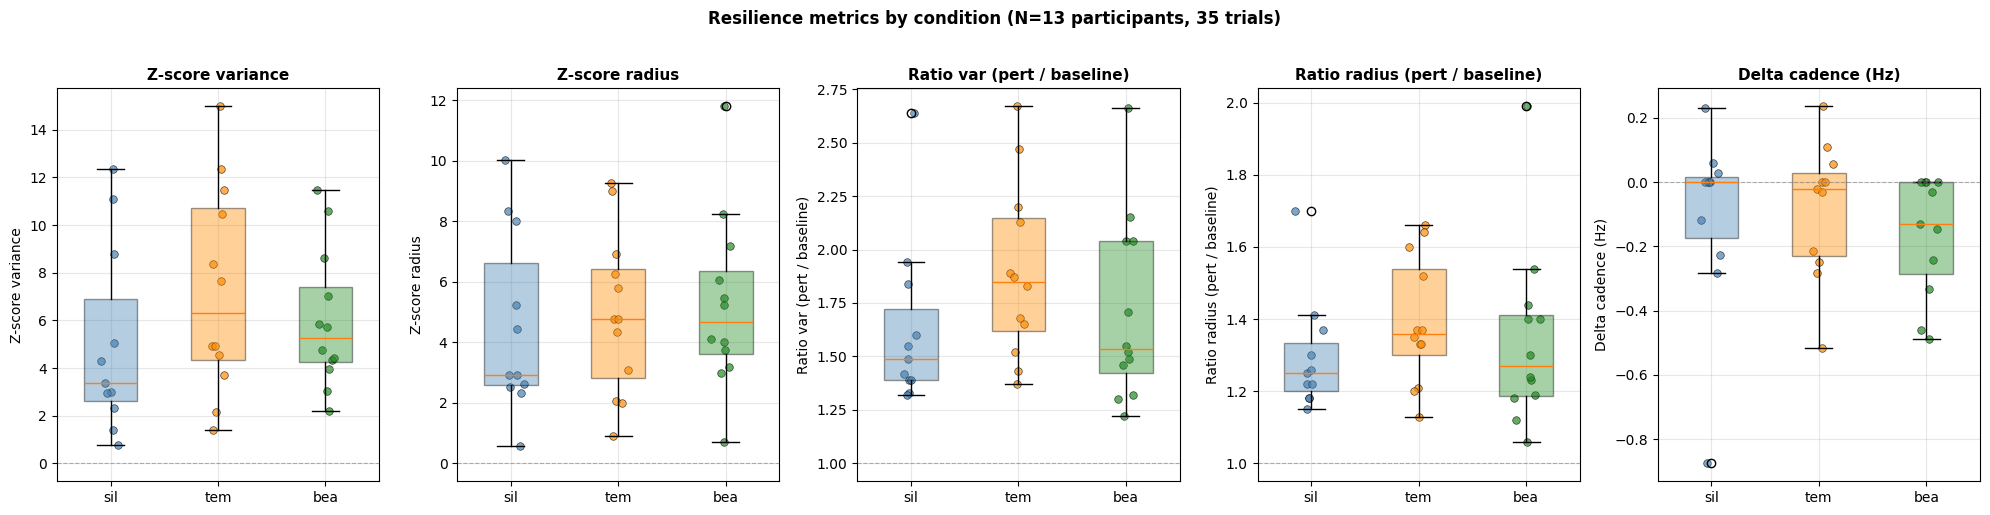

In [6]:
plots.plot_resilience_boxplots(df_res,
    save_to=OUT_FIGURES / '04_metrics_by_condition.png')
plt.show()

   ✅ Figure sauvegardée : C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\outputs\figures\04_individual_trajectories.png


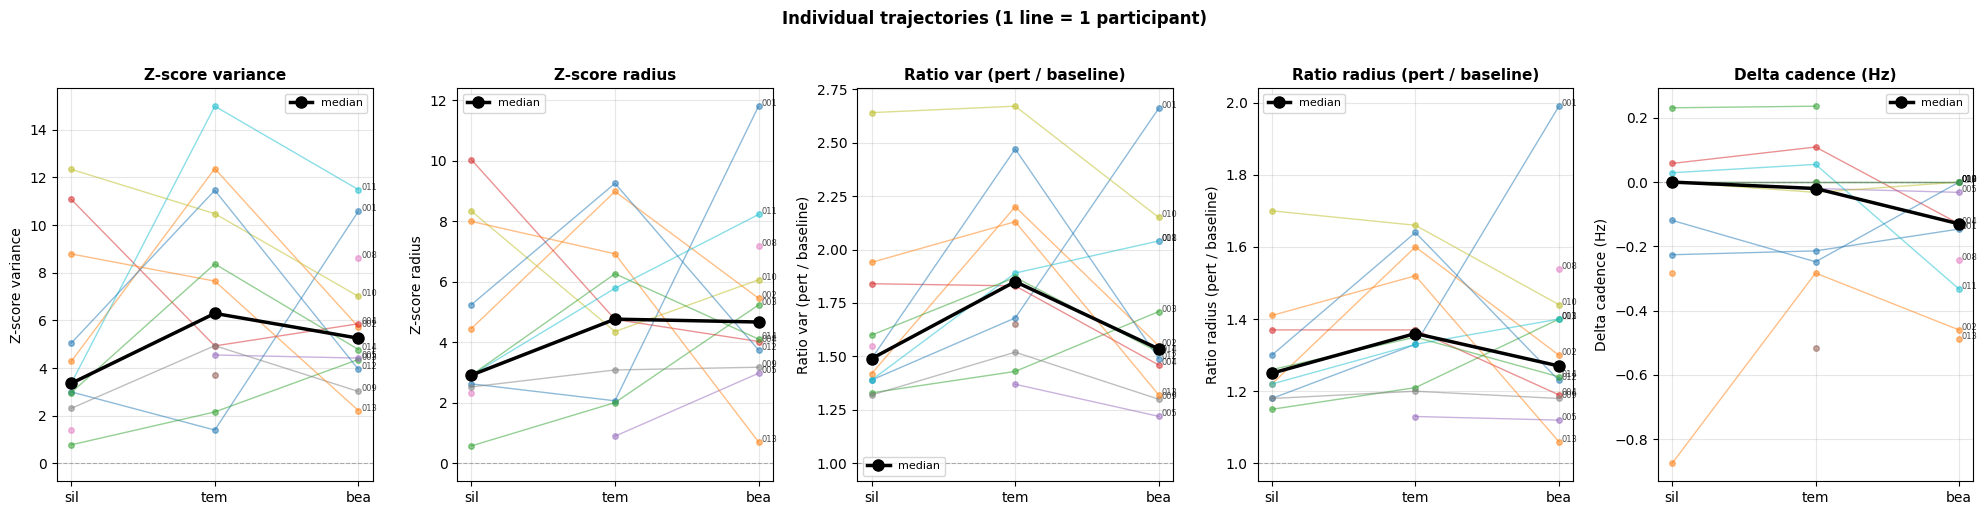

In [7]:
plots.plot_resilience_individual_trajectories(df_res,
    save_to=OUT_FIGURES / '04_individual_trajectories.png')
plt.show()

## 4. Export

In [8]:
out_path = resilience_workflow.export(df_res)
n_complete = df_res[metric_cols].notna().all(axis=1).sum()
print(f"✅ Exported: {out_path}")
print(f"   {len(df_res)} trials, {df_res['participant'].nunique()} participants")
print(f"   {n_complete} trials with all 5 metrics valid")

✅ Exported: C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\outputs\tables\04_resilience_metrics.csv
   35 trials, 13 participants
   33 trials with all 5 metrics valid
